In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO
from pathlib import Path

bestand = Path("/home/niels/BEP-Niels/Data Lobith/data grdc/6435060_Q_Day.Cmd.txt")

df = pd.read_csv(
    bestand,
    sep=";",
    comment="#",
    skipinitialspace=True,
    na_values=-999.000,
    encoding="latin1"
)

df.columns = df.columns.str.strip()

df = df.rename(columns={"YYYY-MM-DD": "date", "Value": "Q_m3s"})

df["date"] = pd.to_datetime(df["date"])
df["Q_m3s"] = pd.to_numeric(df["Q_m3s"])

df = df.dropna(subset=["Q_m3s"])



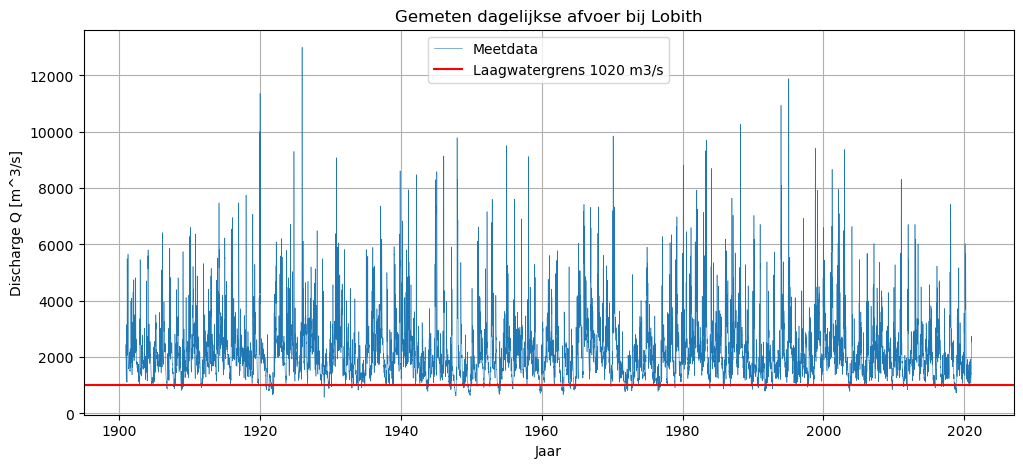

In [3]:
plt.figure(figsize=(12, 5))

plt.plot(df["date"], df["Q_m3s"], linewidth=0.4, label='Meetdata')
plt.axhline(1020, label='Laagwatergrens 1020 m3/s', color='r')

plt.xlabel("Jaar")
plt.ylabel("Discharge Q [m^3/s]")
plt.title("Gemeten dagelijkse afvoer bij Lobith")
plt.legend()
plt.grid()
plt.show()